In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pickle
from scipy.stats import norm

In [ ]:
try:
    plt.rcParams["font.family"] = "Times New Roman"
except:
    from matplotlib import font_manager

    font_manager.fontManager.addfont("/home1/beigejin/Times.ttc")
    plt.rc("font", family="serif", serif=["Times"])
    plt.rcParams["mathtext.fontset"] = "custom"
    plt.rcParams["mathtext.rm"] = "Times"
plt.rcParams["font.size"] = 16
SAVEFIG = False
SAVEDATA = False

In [3]:
df = pd.read_csv("simu2b_data/exp1.csv")
df

,cycle,trial,phase,type,word1,word2,response,RT,correct,lag,serPos1,serPos2,subj,intactLag,prevResponse,prevRT
0,0,-1,study,intact,formal,positive,-1,-1.000,-1,-1,0,0,101,0,0,0
1,0,0,study,intact,skin,careful,-1,-1.000,-1,-1,1,1,101,0,0,0
2,0,1,study,intact,upon,miss,-1,-1.000,-1,-1,2,2,101,0,0,0
3,0,2,study,intact,single,tradition,-1,-1.000,-1,-1,3,3,101,0,0,0
4,0,3,study,intact,prove,airport,-1,-1.000,-1,-1,4,4,101,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107438,7,54,test,intact,typical,month,1,0.937,1,-1,10,10,213,2,1,0
107439,7,55,test,rearranged,miles,pretty,1,1.077,0,3,7,4,213,0,0,0
107440,7,56,test,rearranged,live,placed,1,0.633,0,5,52,47,213,0,0,0
107441,7,57,test,rearranged,cancer,matter,0,0.792,1,1,51,50,213,0,0,0


In [4]:
df_test = df.query("phase == 'test'").copy()
df_test

,cycle,trial,phase,type,word1,word2,response,RT,correct,lag,serPos1,serPos2,subj,intactLag,prevResponse,prevRT
60,0,-1,test,rearranged,waste,degree,0,2.312,1,2,12,10,101,0,0,0
61,0,0,test,rearranged,needed,able,0,3.542,1,1,27,28,101,0,0,0
62,0,1,test,rearranged,single,clean,0,2.084,1,3,3,6,101,0,0,0
63,0,2,test,rearranged,train,useful,0,1.669,1,2,55,57,101,0,0,0
64,0,3,test,rearranged,knees,various,0,2.326,1,5,44,49,101,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107438,7,54,test,intact,typical,month,1,0.937,1,-1,10,10,213,2,1,0
107439,7,55,test,rearranged,miles,pretty,1,1.077,0,3,7,4,213,0,0,0
107440,7,56,test,rearranged,live,placed,1,0.633,0,5,52,47,213,0,0,0
107441,7,57,test,rearranged,cancer,matter,0,0.792,1,1,51,50,213,0,0,0


## Data Clean

In [5]:
np.unique(df.subj).size

112

In [6]:
# exlude extreme RTs
df_test = df_test.query("0.2 <= RT <= 8").copy()

In [7]:
# # get yes rate
# df_yesrate = df_test.groupby(["subj", "type"]).correct.agg(["sum", "count"]).reset_index()
# df_yesrate["yes_rate"] = (df_yesrate["sum"] + 0.5) / (df_yesrate["count"] + 1)
# df_yesrate = df_yesrate.pivot(index="subj", columns="type", values="yes_rate").reset_index()
# df_yesrate["hr"] = df_yesrate["intact"]
# df_yesrate["far"] = 1 - df_yesrate["rearranged"]
# df_yesrate

In [8]:
# get yes rate
df_yesrate = df_test.groupby(["subj", "type"]).correct.mean().to_frame(name="yes_rate").reset_index()
df_yesrate = df_yesrate.pivot(index="subj", columns="type", values="yes_rate").reset_index()
df_yesrate["hr"] = df_yesrate["intact"]
df_yesrate["far"] = 1 - df_yesrate["rearranged"]
df_yesrate

type,subj,intact,rearranged,hr,far
0,101,0.765690,0.891667,0.765690,0.108333
1,102,0.287500,0.758333,0.287500,0.241667
2,103,0.866667,0.908333,0.866667,0.091667
3,104,0.508333,0.612500,0.508333,0.387500
4,105,0.575000,0.627615,0.575000,0.372385
...,...,...,...,...,...
107,210,0.209205,0.850000,0.209205,0.150000
108,211,0.495833,0.820833,0.495833,0.179167
109,212,0.564854,0.472340,0.564854,0.527660
110,213,0.641667,0.529167,0.641667,0.470833


In [9]:
# calculate d prime
df_yesrate["hr_z"] = norm.ppf(df_yesrate.hr)
df_yesrate["far_z"] = norm.ppf(df_yesrate.far)
df_yesrate["d_prime"] = df_yesrate.hr_z - df_yesrate.far_z
df_yesrate

type,subj,intact,rearranged,hr,far,hr_z,far_z,d_prime
0,101,0.765690,0.891667,0.765690,0.108333,0.724727,-1.235440,1.960168
1,102,0.287500,0.758333,0.287500,0.241667,-0.560703,-0.700951,0.140248
2,103,0.866667,0.908333,0.866667,0.091667,1.110772,-1.330562,2.441333
3,104,0.508333,0.612500,0.508333,0.387500,0.020890,-0.285841,0.306731
4,105,0.575000,0.627615,0.575000,0.372385,0.189118,-0.325543,0.514662
...,...,...,...,...,...,...,...,...
107,210,0.209205,0.850000,0.209205,0.150000,-0.809183,-1.036433,0.227251
108,211,0.495833,0.820833,0.495833,0.179167,-0.010444,-0.918546,0.908101
109,212,0.564854,0.472340,0.564854,0.527660,0.163286,0.069388,0.093899
110,213,0.641667,0.529167,0.641667,0.470833,0.362917,-0.073175,0.436093


In [10]:
df_yesrate.query("d_prime < 0")

type,subj,intact,rearranged,hr,far,hr_z,far_z,d_prime
79,181,0.404255,0.502128,0.404255,0.497872,-0.242348,-0.005333,-0.237015
88,190,0.292887,0.658120,0.292887,0.341880,-0.544970,-0.407337,-0.137633


In [11]:
# two subjects are excluded
bad_subj = df_yesrate.query("d_prime < 0").subj.to_numpy()
bad_subj

array([181, 190])

In [12]:
# clean rt and first two trials
df_test = df.query("subj not in @bad_subj").copy()
df_test = df_test.query("RT > 0.5").copy()
df_test = df_test.query("trial > 0").copy()
df_test

,cycle,trial,phase,type,word1,word2,response,RT,correct,lag,serPos1,serPos2,subj,intactLag,prevResponse,prevRT
62,0,1,test,rearranged,single,clean,0,2.084,1,3,3,6,101,0,0,0
63,0,2,test,rearranged,train,useful,0,1.669,1,2,55,57,101,0,0,0
64,0,3,test,rearranged,knees,various,0,2.326,1,5,44,49,101,0,0,0
65,0,4,test,intact,skin,careful,1,1.407,1,-1,1,1,101,0,0,0
66,0,5,test,intact,doctor,contrast,0,4.056,0,-1,35,35,101,34,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107438,7,54,test,intact,typical,month,1,0.937,1,-1,10,10,213,2,1,0
107439,7,55,test,rearranged,miles,pretty,1,1.077,0,3,7,4,213,0,0,0
107440,7,56,test,rearranged,live,placed,1,0.633,0,5,52,47,213,0,0,0
107441,7,57,test,rearranged,cancer,matter,0,0.792,1,1,51,50,213,0,0,0


## Overall HR and FAR

In [13]:
# get yes rate
df_hrfar = df_test.groupby(["subj", "type"]).correct.mean().to_frame(name="yes_rate").reset_index()
df_hrfar = df_hrfar.pivot(index="subj", columns="type", values="yes_rate").reset_index()
df_hrfar["hr"] = df_hrfar["intact"]
df_hrfar["far"] = 1 - df_hrfar["rearranged"]
df_hrfar

type,subj,intact,rearranged,hr,far
0,101,0.761702,0.894737,0.761702,0.105263
1,102,0.287554,0.759825,0.287554,0.240175
2,103,0.860870,0.905983,0.860870,0.094017
3,104,0.506494,0.625000,0.506494,0.375000
4,105,0.581897,0.634361,0.581897,0.365639
...,...,...,...,...,...
105,210,0.211207,0.844156,0.211207,0.155844
106,211,0.502183,0.814159,0.502183,0.185841
107,212,0.619355,0.459459,0.619355,0.540541
108,213,0.644737,0.525581,0.644737,0.474419


In [14]:
df_hrfar_plot = pd.melt(df_hrfar, id_vars=["subj"], value_vars=["hr", "far"], var_name="type", value_name="yes_rate")
df_hrfar_plot

,subj,type,yes_rate
0,101,hr,0.761702
1,102,hr,0.287554
2,103,hr,0.860870
3,104,hr,0.506494
4,105,hr,0.581897
...,...,...,...
215,210,far,0.155844
216,211,far,0.185841
217,212,far,0.540541
218,213,far,0.474419


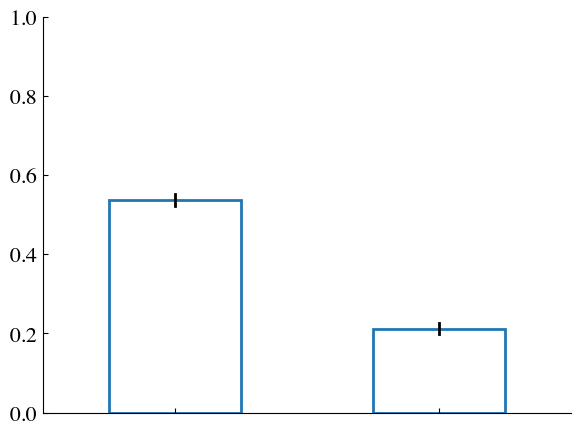

In [29]:
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

sns.barplot(
    data=df_hrfar_plot,
    x="type",
    y="yes_rate",
    width=0.5,
    errorbar="se",
    ax=ax,
    err_kws={"lw": 2, "color": "black"},
    facecolor="white",
    edgecolor="C0",
    lw=2,
)

ax.set_xticks(ticks=[0, 1], labels=["HR", "FAR"])
ax.set_yticks(ticks=np.arange(0, 1.1, 0.2))
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0, 1)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")

ax.spines[["right", "top"]].set_visible(False)
ax.set(xlabel=None, ylabel=None)

if SAVEFIG:
    plt.tick_params(labelbottom=False)
    plt.savefig(f"simu2b_fig/simu2b_Osth_hrfar.pdf")
plt.show()

## Far with Lag

In [19]:
df_lure = df_test.query("type == 'rearranged'").copy()
df_farlag = df_lure.groupby(["subj", "lag"]).correct.mean().to_frame(name="yes_rate").reset_index()
df_farlag["far"] = 1 - df_farlag["yes_rate"]
df_farlag

,subj,lag,yes_rate,far
0,101,1,0.954545,0.045455
1,101,2,0.800000,0.200000
2,101,3,0.957447,0.042553
3,101,4,0.869565,0.130435
4,101,5,0.891304,0.108696
...,...,...,...,...
545,1150,1,0.729167,0.270833
546,1150,2,0.840909,0.159091
547,1150,3,0.829787,0.170213
548,1150,4,0.787234,0.212766


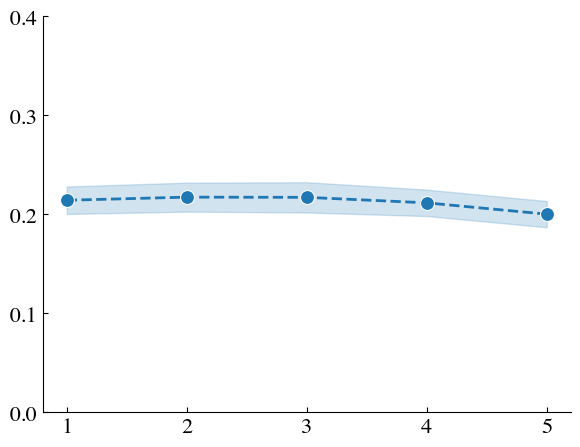

In [32]:
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

sns.lineplot(
    data=df_farlag,
    x="lag",
    y="far",
    marker="o",
    markersize=10,
    errorbar="se",
    err_style="band",
    ax=ax,
    linewidth=2,
    linestyle="--",
)

ax.set_xticks(ticks=np.arange(1, 6))
ax.set_yticks(ticks=np.arange(0, 0.41, 0.1))
ax.set_xlim(0.8, 5.2)
ax.set_ylim(0, 0.4)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")

ax.spines[["right", "top"]].set_visible(False)
ax.set(xlabel=None, ylabel=None)

if SAVEFIG:
    plt.savefig(f"simu2b_fig/simu2b_Osth_lag.pdf")
plt.show()

In [21]:
hr_gt = df_hrfar_plot.query("type == 'hr'").yes_rate.mean()
hr_std_gt = df_hrfar_plot.query("type == 'hr'").yes_rate.std()
far_gt = df_farlag.groupby("lag").far.mean().to_numpy()
far_std_gt = df_farlag.groupby("lag").far.std().to_numpy()
hr_gt, hr_std_gt, far_gt, far_std_gt

(0.5366186381796584,
 0.1633487638481977,
 array([0.21428165, 0.2174274 , 0.21721617, 0.21166567, 0.20021831]),
 array([0.14578635, 0.15351747, 0.16036269, 0.14002328, 0.13892722]))

In [ ]:
# save gt as pkl
if SAVEDATA:
    with open("simu2b_data/simu2b_gt.pkl", "wb") as f:
        pickle.dump(hr_gt, f)
        pickle.dump(hr_std_gt, f)
        pickle.dump(far_gt, f)
        pickle.dump(far_std_gt, f)